Part 1: Reinforcement Learning

Task 1 (40 points): Implement value iteration or policy iteration for a small discrete Markov Decision Process (MDP).
You may use a grid world, FrozenLake, inventory control, or another small discrete environment approved in class.

Perform the following:

• Clearly define the state space, action space, reward structure, and discount factor.

• Implement either value iteration or policy iteration and compute the final policy.

• Show the learned value function and the final policy in a readable form.

• Run at least one small experiment showing how the policy changes when you vary either the discount factor or the reward design.

• Briefly discuss why this setup is an MDP and what the learned policy is doing.

In [14]:
import numpy as np

# define the environment
grid_size = (4, 4)
terminal_states = [(0, 3), (1, 3)]
rewards = np.full(grid_size, -0.04)
rewards[0, 3] = 1.0
rewards[1, 3] = -1.0

gamma = 0.9
theta = 1e-4

actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1)
}

# function
def is_valid_state(s):
    i, j = s
    return 0 <= i < grid_size[0] and 0 <= j < grid_size[1]

def step(state, action):
    if state in terminal_states:
        return state

    di, dj = actions[action]
    ni, nj = state[0] + di, state[1] + dj

    if not is_valid_state((ni, nj)):
        return state
    return (ni, nj)
def run_value_iteration(gamma):
    V = np.zeros(grid_size)

    while True:
        delta = 0
        new_V = np.copy(V)

        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state = (i, j)

                if state in terminal_states:
                    continue

                values = []
                for a in actions:
                    next_state = step(state, a)
                    r = rewards[next_state]
                    values.append(r + gamma * V[next_state])

                best_value = max(values)
                new_V[state] = best_value
                delta = max(delta, abs(V[state] - best_value))

        V = new_V
        if delta < theta:
            break

    # extract policy
    policy = np.empty(grid_size, dtype=object)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            state = (i, j)

            if state in terminal_states:
                policy[state] = "T"
                continue

            best_action = None
            best_value = -float("inf")

            for a in actions:
                next_state = step(state, a)
                r = rewards[next_state]
                val = r + gamma * V[next_state]

                if val > best_value:
                    best_value = val
                    best_action = a

            policy[state] = best_action

    return V, policy

# policy
def extract_policy(V, gamma):
    policy = np.empty(grid_size, dtype=object)

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            state = (i, j)

            if state in terminal_states:
                policy[state] = "T"
                continue

            best_action = None
            best_value = -float("inf")

            for a in actions:
                next_state = step(state, a)
                r = rewards[next_state]
                val = r + gamma * V[next_state]

                if val > best_value:
                    best_value = val
                    best_action = a

            policy[state] = best_action

    return policy

# print
V1, policy1 = run_value_iteration(0.9)
V2, policy2 = run_value_iteration(0.5)

print("Value Function (gamma = 0.9):")
print(np.round(V1, 3))

print("\nValue Function (gamma = 0.5):")
print(np.round(V2, 3))

print("\nPolicy (gamma = 0.9):")
for row in policy1:
    print(row)

print("\nPolicy (gamma = 0.5):")
for row in policy2:
    print(row)

Value Function (gamma = 0.9):
[[0.734 0.86  1.    0.   ]
 [0.621 0.734 0.86  0.   ]
 [0.519 0.621 0.734 0.621]
 [0.427 0.519 0.621 0.519]]

Value Function (gamma = 0.5):
[[ 0.19   0.46   1.     0.   ]
 [ 0.055  0.19   0.46   0.   ]
 [-0.012  0.055  0.19   0.055]
 [-0.046 -0.012  0.055 -0.012]]

Policy (gamma = 0.9):
['R' 'R' 'R' 'T']
['U' 'U' 'U' 'T']
['U' 'U' 'U' 'L']
['U' 'U' 'U' 'U']

Policy (gamma = 0.5):
['R' 'R' 'R' 'T']
['U' 'U' 'U' 'T']
['U' 'U' 'U' 'L']
['U' 'U' 'U' 'U']


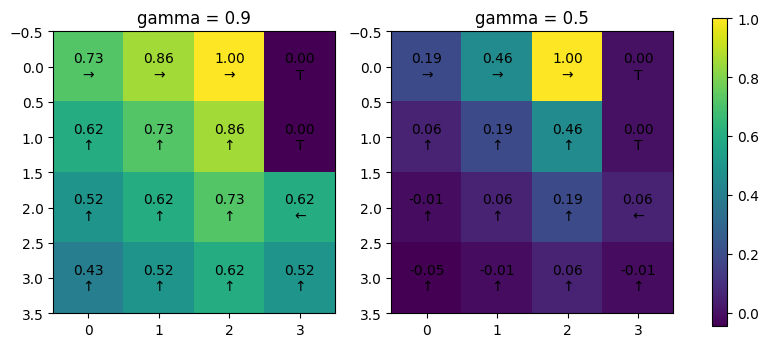

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
arrow_map = {
    "U": "↑",
    "D": "↓",
    "L": "←",
    "R": "→",
    "T": "T"
}
for ax, V, policy, title in zip(
    axes,
    [V1, V2],
    [policy1, policy2],
    ["gamma = 0.9", "gamma = 0.5"]
):
    im = ax.imshow(V)

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            text = f"{V[i,j]:.2f}\n{arrow_map[policy[i,j]]}"
            ax.text(j, i, text, ha='center', va='center')

    ax.set_title(title)

plt.colorbar(im, ax=axes)
plt.show()

We model the problem as a Markov Decision Process (MDP). The state space consists of all cells in a 4×4 grid. The action space includes four deterministic actions: up, down, left, and right. The reward structure assigns a step penalty of −0.04 for each move, a reward of +1 at the goal state (0,3), and −1 at the negative terminal state (1,3). The discount factor is set to γ = 0.9. This setup satisfies the Markov property because the next state and reward depend only on the current state and action.

We implement value iteration to compute the optimal value function. The algorithm iteratively updates the value function using the Bellman optimality equation until convergence. The optimal policy is then extracted by selecting the action that maximizes the expected return at each state.

The resulting value function exhibits a clear gradient, with higher values near the goal and lower values further away. States closer to the goal have higher expected returns, while states farther away accumulate more step penalties. The optimal policy consistently directs the agent toward the goal while avoiding the negative terminal state. For example, at state (2,3), the policy selects a leftward action to avoid transitioning into the negative terminal state.

To study the effect of the discount factor, we compare results for γ = 0.9 and γ = 0.5. When γ = 0.9, the agent places more weight on future rewards, leading to higher value estimates across the grid. When γ = 0.5, the agent becomes more short-sighted, resulting in significantly lower values and even negative values in some states due to accumulated penalties.

Interestingly, the optimal policy remains unchanged under both discount factors. In both cases, the agent moves toward the goal and avoids the negative terminal state. This is because the relative ordering of action values at each state is preserved, even though the magnitude of the value function changes. Therefore, the discount factor affects the scale of the value function and the degree of long-term planning, but does not alter the optimal policy in this setting.


Part 2: Mini Research Task on a Novel AI Topic

Task 2 (60 points): Complete one scoped mini research task on a recent AI topic. Diffusion models are strongly encouraged, but you may choose another novel topic.

Examples of acceptable topics include diffusion models, consistency models, flow matching, multimodal foundation models, retrieval-augmented generation, parameter-efficient fine-tuning, graph neural networks, or another recent topic in the field of AI.
Perform the following:

• Select one focused topic and identify at least two technical sources. At least one source should be a primary source such as a research paper, official documentation, or a model card.

• Explain the problem the method is trying to solve, the core idea behind the method, and the main architecture or training objective in your own words.

• Include one small hands-on component. For example, you may run a simple demo, inspect a pretrained model or pipeline, reproduce one small figure or result, compare two variants, or analyze how one key design choice affects outputs.

• If you choose diffusion models, possible hands-on directions include comparing different numbers of denoising steps, comparing schedulers, testing prompt sensitivity, or explaining the forward and reverse diffusion process with a compact experiment.

• Include at least one figure, table, or carefully labeled output example that supports your analysis.

• Discuss at least two limitations, risks, or open challenges related to the method.

• Propose one concrete extension, improvement, or follow-up experiment that you would pursue next.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

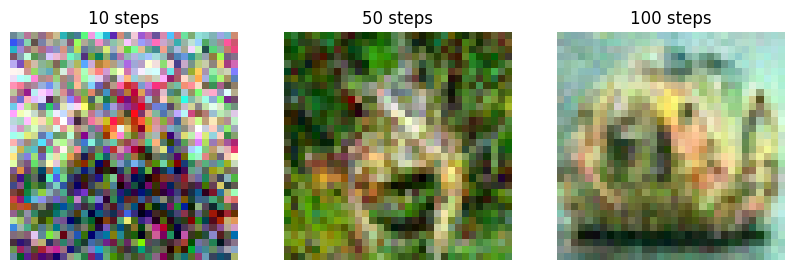

In [ ]:
from diffusers import DDPMPipeline
import torch
import matplotlib.pyplot as plt

pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipe.to("cpu")

steps_list = [10, 50, 100]
images = []

for steps in steps_list:
    img = pipe(num_inference_steps=steps).images[0]
    images.append(img)

# plot
plt.figure(figsize=(10,3))
for i, img in enumerate(images):
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"{steps_list[i]} steps")
    plt.axis("off")

plt.show()

**Method Explanation**

Diffusion models, such as Denoising Diffusion Probabilistic Models (DDPM), are a class of generative models that learn to generate data by reversing a gradual noising process (Ho et al., 2020). The key problem they address is how to generate high-quality samples from a simple distribution (e.g., Gaussian noise) by learning a sequence of transformations.

The core idea of DDPM is to define a forward process that gradually adds Gaussian noise to data over a sequence of time steps, eventually transforming it into pure noise. A neural network, typically based on a U-Net architecture, is then trained to learn the reverse process, which removes noise step by step to reconstruct the original data. Instead of directly predicting the clean image, the model is trained to predict the noise added at each step using a mean squared error objective, which stabilizes training (Ho et al., 2020; Nichol & Dhariwal, 2021).

During inference, the model starts from random noise and iteratively applies the learned denoising process. The number of denoising steps is a key design choice that directly affects both the computational cost and the quality of generated samples (Hugging Face, 2023).

**Experiment results**

This experiment evaluates how the number of denoising steps affects the quality of images generated by a diffusion model. We use a pretrained DDPM model (google/ddpm-cifar10-32) provided by the Hugging Face Diffusers library (Hugging Face, 2023) and generate images with 10, 50, and 100 inference steps.

Figure 1 shows the generated CIFAR-10 images under different numbers of denoising steps. With 10 steps, the generated image appears highly noisy and lacks recognizable structure, indicating that the reverse diffusion process is too coarse to reconstruct meaningful data. At 50 steps, the image begins to exhibit recognizable shapes and color patterns, although it remains somewhat blurry. At 100 steps, the generated image becomes significantly clearer, with more coherent structure and reduced noise. However, the improvement from 50 to 100 steps is less pronounced than from 10 to 50 steps, suggesting diminishing returns as the number of steps increases.

Overall, the results demonstrate a trade-off between computational cost and sample quality. Increasing the number of denoising steps improves image quality, but the improvement is sublinear while computational cost grows approximately linearly.

One limitation of this approach is that DDPM requires many sequential denoising steps, making inference computationally expensive. Another limitation is that this experiment is conducted on low-resolution CIFAR-10 images, which may not generalize to higher-resolution or real-world datasets.

A possible extension is to compare different sampling methods, such as DDPM and DDIM, under the same number of inference steps to evaluate whether faster samplers can achieve similar image quality. Future work could also include quantitative evaluation metrics such as FID score to provide a more objective assessment of generation quality.

**References**

Ho, Jonathan, Ajay Jain, and Pieter Abbeel. "Denoising diffusion probabilistic models." Advances in neural information processing systems 33 (2020): 6840-6851.

Nichol, Alexander Quinn, and Prafulla Dhariwal. "Improved denoising diffusion probabilistic models." International conference on machine learning. PMLR, 2021.

Hugging Face. (2023). Diffusers Documentation. https://huggingface.co/docs/diffusers


Task 3 is for 6000 level only

Task 3 (100 points): Select one recent AI/ML research paper from 2024 to 2026 that is related to your chosen novel topic or another advanced course topic that interests you.
Prepare a technical review and a small reproducibility component.

• Write a 2-to-4-page review (submit a pdf or a link to the pdf) summarizing the problem, method, dataset, evaluation metrics, and main findings.

• Identify at least two strengths, two limitations, and one reproducibility challenge in the paper.

• Reproduce one figure, table, ablation, or small experiment from the paper. If full reproduction is not feasible, perform a structured reproducibility audit and explain exactly what blocked reproduction.

• Suggest one concrete extension or follow-up experiment that would strengthen the paper.

• Submit your review together with any code, notebook, and references used.
Clear reasoning, reproducibility, and presentation quality matter.

model_index.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

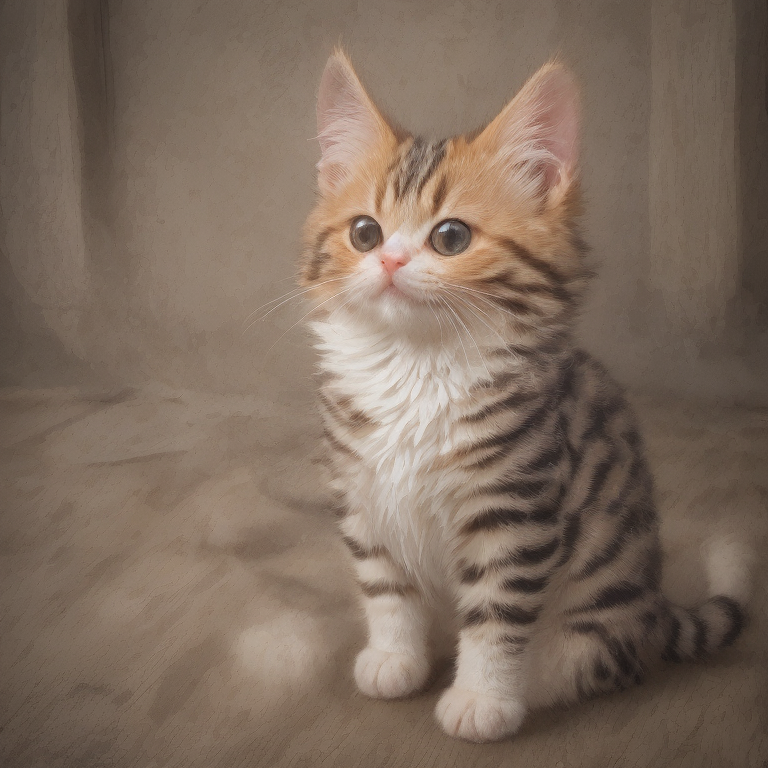

In [3]:
from diffusers import DiffusionPipeline
import torch

# LCM model
pipe = DiffusionPipeline.from_pretrained(
    "SimianLuo/LCM_Dreamshaper_v7",
    torch_dtype=torch.float32
)
pipe.to("cpu")

prompt = "a cute cat"

# few-step generation
image = pipe(prompt, num_inference_steps=4).images[0]

image

In [1]:
from diffusers import DDPMPipeline

pipe_ddpm = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipe_ddpm.to("cpu")

image_ddpm = pipe_ddpm(num_inference_steps=50).images[0]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

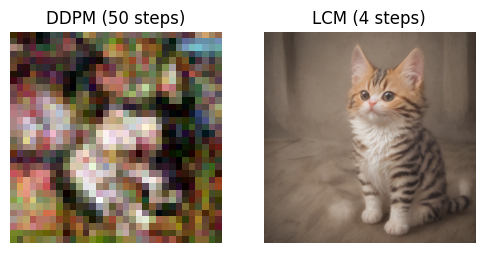

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(image_ddpm)
plt.title("DDPM (50 steps)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image)
plt.title("LCM (4 steps)")
plt.axis("off")

plt.show()